# Game 4 - The Zero-to-Hero Sprint

**Team:** Ded_Sec

Both models were initialized randomly. No pretrained weights, encoders, or
external embeddings were used.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = Path.cwd()
results = pd.read_csv(OUTPUT_DIR / "scratch_model_results.csv")
image_history = pd.read_csv(OUTPUT_DIR / "image_training_history.csv")
text_history = pd.read_csv(OUTPUT_DIR / "text_training_history.csv")
errors = pd.read_csv(OUTPUT_DIR / "scratch_error_analysis.csv")

display(results)
display(errors.head(20))


,model_id,modality,architecture,accuracy,macro_f1,precision,recall,training_time,inference_time,notes
0,scratch_image_cnn,image,"4-block CNN, random initialization",0.8428,0.842209,0.848014,0.8428,338.972385,9.860769,"841,570 parameters; no pretrained weights; asp..."
1,scratch_text_cnn,text,learned embedding + 3/4/5-kernel TextCNN,0.7112,0.710791,0.712401,0.7112,23.864978,0.075068,"1,509,890 parameters; vocabulary=10,251; rando..."


,sample_id,modality,true_label,predicted_label,confidence,case_type,observed_input_flags,text,image_path
0,train__006397,image,real,fake,0.993451,high_confidence_error,image_low_resolution|image_low_sharpness,People waited Tuesday at the airport in Taclob...,games/game2_data_reconnaissance/modified_image...
1,train__007921,image,real,fake,0.992635,high_confidence_error,none,United States Marines searched for debris from...,data/images/train__007921.jpg
2,train__005181,image,real,fake,0.989243,high_confidence_error,none,"Tons of marijuana — 134 tons, in fact — sat on...",data/images/train__005181.jpg
3,train__006743,image,real,fake,0.986847,high_confidence_error,text_was_missing,MISSING_TEXT,data/images/train__006743.jpg
4,train__008599,image,real,fake,0.983819,high_confidence_error,image_low_resolution|image_low_sharpness,Investigators at the scene of the fatal shooti...,games/game2_data_reconnaissance/modified_image...
5,train__005726,image,real,fake,0.981517,high_confidence_error,none,A man chants anti-government slogans during a ...,data/images/train__005726.jpg
6,train__008589,image,real,fake,0.980994,high_confidence_error,image_low_resolution|image_low_sharpness,A Baltimore officer answers questions from nei...,games/game2_data_reconnaissance/modified_image...
7,train__009115,image,real,fake,0.975791,high_confidence_error,none,Opposition party lawmakers held signs reading ...,data/images/train__009115.jpg
8,train__005859,image,real,fake,0.975124,high_confidence_error,none,Protesters prayed during a demonstration at Ta...,data/images/train__005859.jpg
9,train__005563,image,real,fake,0.974993,high_confidence_error,none,Shiites marched in a religious procession last...,data/images/train__005563.jpg


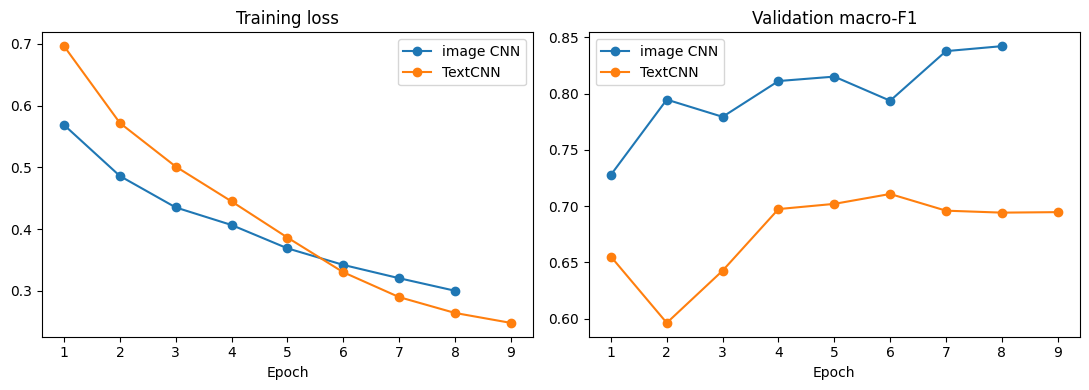

cases
modality case_type                   
image    error                     50
         high_confidence_error     50
         uncertain_correct         30
text     error                     50
         high_confidence_error     50
         uncertain_correct         30

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for history, label in [
    (image_history, "image CNN"),
    (text_history, "TextCNN"),
]:
    axes[0].plot(
        history["epoch"], history["train_loss"], marker="o", label=label
    )
    axes[1].plot(
        history["epoch"], history["val_macro_f1"], marker="o", label=label
    )
axes[0].set_title("Training loss")
axes[1].set_title("Validation macro-F1")
for ax in axes:
    ax.set_xlabel("Epoch")
    ax.legend()
plt.tight_layout()
plt.show()

display(errors.groupby(["modality", "case_type"]).size().to_frame("cases"))


## Final Conclusion

The scratch image CNN reached accuracy=0.8428 and macro-F1=0.8422. The scratch TextCNN reached accuracy=0.7112 and macro-F1=0.7108. The stronger scratch modality was image. Image limitations include low-resolution inputs, quality variation, and learning visual semantics from only 9,000 examples. Text limitations include a task-specific vocabulary, short sequence truncation, and no pretrained language knowledge. Both models are honest random-initialization baselines for Game 5.
